In [17]:
!nvidia-smi

Wed Sep  2 05:34:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
# import torch, triton, numpy and matplotlib
import torch
from torch.utils.cpp_extension import load_inline # for loading cuda code
import triton
import triton.language as tl
import numpy as np
import matplotlib.pyplot as plt

# print versions of the libraries
print(f"torch.__version__: {torch.__version__}")
print(f"triton.__version__: {triton.__version__}")
print(f"np.__version__: {np.__version__}")

torch.__version__: 2.11.0+cu128
triton.__version__: 3.6.0
np.__version__: 2.1.3


In [19]:
# 1. default torch square function
x=torch.randn(1000)
a=torch.square(x)

# 2. Simple Square Function
def square_simple(x):
    return x*x

# 3. torch.pow (commented out for now)
def square_pow(x):
    return torch.pow(x, 2)


In [20]:
!pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 7.1 MB/s eta 0:00:00


In [21]:

# 4. Custom CUDA Square Kernel

cpp_source = r"""
#include <torch/extension.h>

torch::Tensor square_cuda(torch::Tensor input);
"""

cuda_source = r"""

#include <torch/extension.h>
// Define the square_kernel function
__global__ void square_kernel(
    const float *input,
    float *output,
    int n
)
{
    // Get the global thread ID/index from the block and thread IDs
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    // If the thread ID is greater than the number of elements, then you will face and OOB error
    if (idx < n) {
        // Square the input element and store it in the output array
        output[idx] = input[idx] * input[idx];
    }
}

// Define the square_cuda function
torch::Tensor square_cuda(torch::Tensor input) {
    input = input.contiguous(); // make the input tensor contiguous in memory
    // Get the number of elements in the input tensor
    int n = input.numel();

    // Create an output tensor with the same shape as the input tensor
    torch::Tensor output = torch::empty_like(input);

    // use 256 threads per block
    int threads = 256;

    // calculate the number of blocks needed
    int blocks = (n + threads - 1) / threads;

    //call the cuda kernel
    square_kernel<<<blocks, threads>>>(
        input.data_ptr<float>(),
        output.data_ptr<float>(),
        n
    );

    // return the output tensor
    return output;
}
"""

# use load_inline to load the kernel
module = load_inline(
    name="square_kernel",
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=["square_cuda"],
    verbose=True
)



In [22]:
# 5. triton square kernel
# in order to use triton to write a square kernel, we need to write a jit function and a launcher function.
# the jit function will be used to define the kernel and the launcher function will be used to launch the kernel.

# jit function
@triton.jit
def square_kernel(
    x_ptr,# pointer to the input array
    y_ptr,# pointer to the output array
    n_elements,# number of elements in the input array
    BLOCK_SIZE: tl.constexpr # block size
):
    '''
    This is the kernel body. This kernel is a simple square kernel that squares the input elements.
    '''

    # get the program id
    pid = tl.program_id(0) # gives program id to the instance
    
    # get the offsets of the thread in the block
    offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)

    # apply mask to avoid out of bounds access
    mask = offsets < n_elements
    
    # load the input elements within the bounds made by the mask
    x = tl.load(x_ptr + offsets, mask=mask)

    # square the input elements
    y = x * x
    
    # store the output elements
    tl.store(y_ptr + offsets, y, mask=offsets < n_elements)

# launcher function for the triton square kernel
def square_triton(x):
    y = torch.empty_like(x) # create an empty tensor with the same shape as x
    n_elements = x.numel() # get the number of elements in x
    BLOCK_SIZE = 1024 # set the block size
    # get number of grids
    grid = lambda meta: (triton.cdiv(n_elements, meta["BLOCK_SIZE"]),)
    square_kernel[grid](x, y, n_elements, BLOCK_SIZE=BLOCK_SIZE) # launch the kernel
    return y




In [23]:
#6. torch.compile version
square_compiled = torch.compile(square_simple)

#7. torch.compile version with triton
square_triton_compiled = torch.compile(square_triton)

In [24]:
N=[2**i for i in [10,14,18,22,26]]

Our goal now is to profile for the latency, effective bandwidth, number of kernels launched, generated code, nsight compute occupancy

Effective Bandwidth = 8N/Tseconds

Latency and effective bandwidth needs to calculated from a benchmark method

In [25]:
impls = {
    "torch.square": torch.square,
    "x*x": square_simple,
    "torch.pow": square_pow,
    "cuda": module.square_cuda,
    "triton": square_triton,
    "compile(x*x)": square_compiled,
    "compile(triton)": square_triton_compiled,
}

latency_ms = {name: [] for name in impls}
bw_gbs = {name: [] for name in impls}

# benchmark function to calculate the latency, effective bandwidth, number of kernels launched, generated code, nsight compute occupancy
def benchmark(func, x, iters=100):
    for _ in range(10):
        func(x)
    torch.cuda.synchronize()
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    start.record()
    for _ in range(iters):
        func(x)
    end.record()
    torch.cuda.synchronize()
    ms = start.elapsed_time(end) / iters
    n = x.numel()
    gbps = (8 * n) / (ms * 1e-3) / 1e9
    return ms, gbps
    

In [26]:
for n in N:
    x = torch.randn(n, device="cuda")
    for name, fn in impls.items():
        ms, gbps = benchmark(fn, x)
        latency_ms[name].append(ms)
        bw_gbs[name].append(gbps)

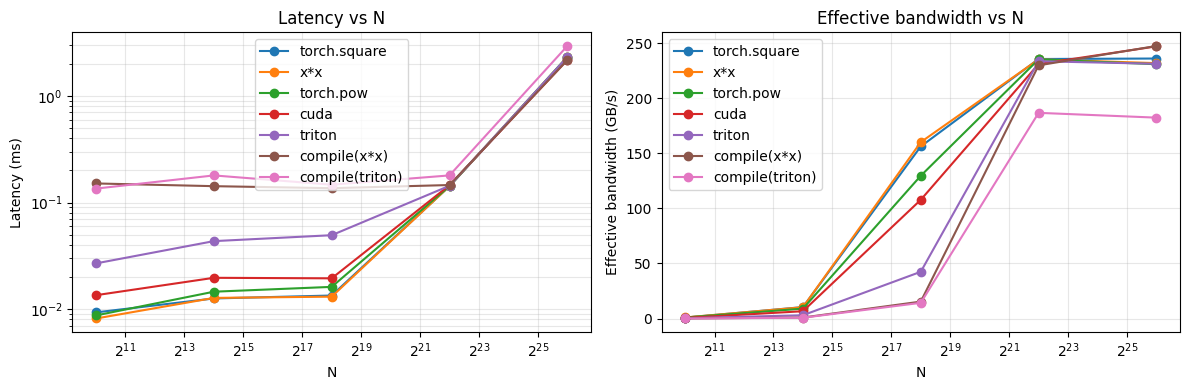

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in impls:
    axes[0].plot(N, latency_ms[name], marker="o", label=name)
    axes[1].plot(N, bw_gbs[name], marker="o", label=name)
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("N")
axes[0].set_ylabel("Latency (ms)")
axes[0].set_title("Latency vs N")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("N")
axes[1].set_ylabel("Effective bandwidth (GB/s)")
axes[1].set_title("Effective bandwidth vs N")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

nsight compute occupancy

We will use this tool called ncu to get nsight compute occupancy data and extract it if possible and make plots and infer from the observations

Written my simple notes about ncu in a separate md file.

In [28]:
!ncu -v

NVIDIA (R) Nsight Compute Command Line Profiler
Copyright (c) 2018-2025 NVIDIA Corporation
Version 2025.1.1.0 (build 35528883) (public-release)


In [29]:
from pathlib import Path
import subprocess, sys
# this is a simple script to run the square kernel and get the occupancy data
Path("square_ncu.py").write_text("""
import argparse, torch
p = argparse.ArgumentParser()
p.add_argument("--n", type=int, required=True)
args = p.parse_args()
x = torch.randn(args.n, device="cuda")
for _ in range(10):
    torch.square(x)
torch.cuda.synchronize()
torch.square(x)
torch.cuda.synchronize()
""")
cmd = [
    "ncu", "--csv", "--page", "raw",
    "--section", "Occupancy",
    "--launch-skip", "10", "--launch-count", "1",
    "--", sys.executable, "square_ncu.py", "--n", str(2**22),
]
print(subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT))

==PROF== Connected to process 7884 (/usr/bin/python3.13)
==PROF== Disconnected from process 7884
"ID","Process ID","Process Name","Host Name","Kernel Name","Context","Stream","Block Size","Grid Size","Device","CC","c2clink__enabled_mask","c2clink__present","derived__pct_occupancy_per_block_size","derived__pct_occupancy_per_register_count","derived__pct_occupancy_per_shared_mem_size","derived_tempMetric0","device__attribute_architecture","device__attribute_async_engine_count","device__attribute_can_flush_remote_writes","device__attribute_can_map_host_memory","device__attribute_can_tex2d_gather","device__attribute_can_use_64_bit_stream_mem_ops","device__attribute_can_use_64_bit_stream_mem_ops_v1","device__attribute_can_use_host_pointer_for_registered_mem","device__attribute_can_use_stream_mem_ops_v1","device__attribute_can_use_stream_wait_value_nor","device__attribute_can_use_stream_wait_value_nor_v1","device__attribute_chip","device__attribute_clock_rate","device__attribute_cluster_laun

In [30]:
!pip install pandas

In [31]:
import io
import pandas as pd
raw = subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT)
def parse_ncu_csv(text: str) -> pd.DataFrame:
    lines = [ln for ln in text.splitlines() if ln.startswith('"ID"') or (ln.startswith('"') and not ln.startswith('"='))]
    # first quoted block is header; skip ==PROF==
    start = next(i for i, ln in enumerate(text.splitlines()) if ln.startswith('"ID"'))
    body = text.splitlines()[start:]
    # row0 = names, row1 = units, row2+ = kernels
    df = pd.read_csv(io.StringIO("\n".join(body)), thousands=",")
    # drop the units row (it becomes row 0 after header)
    df = df.iloc[1:].reset_index(drop=True)
    return df
df = parse_ncu_csv(raw)

In [32]:
df

,ID,Process ID,Process Name,Host Name,Kernel Name,Context,Stream,Block Size,Grid Size,Device,...,sm__warps_active.max.per_cycle_active,sm__warps_active.min.pct_of_peak_sustained_active,sm__warps_active.min.per_cycle_active,sm__warps_active.sum.pct_of_peak_sustained_active,sm__warps_active.sum.per_cycle_active,smsp__maximum_warps_avg_per_active_cycle,smsp__warps_active.avg.peak_sustained,smsp__warps_active.max.peak_sustained,smsp__warps_active.min.peak_sustained,smsp__warps_active.sum.peak_sustained
0,0.0,7961.0,python3.13,127.0.0.1,"void vectorized_elementwise_kernel<4, void unn...",1.0,7.0,"(128, 1, 1)","(4096, 1, 1)",0.0,...,29.64,86.19,27.58,89.88,"1,150.52",8,8,8,8,"1,280"


Occupancy achieved is 89.46%! (sm__warps_active.avg.pct_of_peak_sustained_active)

In [33]:
print(f"Block size :: launch__block_size : {df['launch__block_size'].values[0]}")
print(f"Grid size :: launch__grid_size : {df['launch__grid_size'].values[0]}")
print(f"Max blocks/SM this config allows :: launch__occupancy_limit_blocks : {df['launch__occupancy_limit_blocks'].values[0]}")
print(f"Occupancy :: sm__warps_active.avg.pct_of_peak_sustained_active : {df['sm__warps_active.avg.pct_of_peak_sustained_active'].values[0]}%")
print(f"Theoretical occupancy % for this config :: sm__maximum_warps_per_active_cycle_pct : {df['sm__maximum_warps_per_active_cycle_pct'].values[0]}%")


Block size :: launch__block_size : 128.0
Grid size :: launch__grid_size : 4096.0
Max blocks/SM this config allows :: launch__occupancy_limit_blocks : 16
Occupancy :: sm__warps_active.avg.pct_of_peak_sustained_active : 89.88%
Theoretical occupancy % for this config :: sm__maximum_warps_per_active_cycle_pct : 100%


In [35]:
from pathlib import Path
import subprocess, sys

Path("square_ncu_cuda.py").write_text(r'''
import argparse
import torch
from torch.utils.cpp_extension import load_inline

cpp_source = r"""
#include <torch/extension.h>
torch::Tensor square_cuda(torch::Tensor input);
"""

cuda_source = r"""
#include <torch/extension.h>
__global__ void square_kernel(const float *input, float *output, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        output[idx] = input[idx] * input[idx];
    }
}
torch::Tensor square_cuda(torch::Tensor input) {
    input = input.contiguous();
    int n = input.numel();
    torch::Tensor output = torch::empty_like(input);
    int threads = 256;
    int blocks = (n + threads - 1) / threads;
    square_kernel<<<blocks, threads>>>(
        input.data_ptr<float>(), output.data_ptr<float>(), n);
    return output;
}
"""

module = load_inline(
    name="square_kernel_ncu",
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=["square_cuda"],
    verbose=False,
)

p = argparse.ArgumentParser()
p.add_argument("--n", type=int, required=True)
args = p.parse_args()
x = torch.randn(args.n, device="cuda")
for _ in range(10):
    module.square_cuda(x)
torch.cuda.synchronize()
module.square_cuda(x)
torch.cuda.synchronize()
''')

cmd = [
    "ncu", "--csv", "--page", "raw",
    "--section", "Occupancy",
    "--launch-skip", "10", "--launch-count", "1",
    "--kernel-name", "regex:square_kernel",
    "--", sys.executable, "square_ncu_cuda.py", "--n", str(2**22),
]
try:
    raw_cuda = subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT)
    print(raw_cuda)
except subprocess.CalledProcessError as e:
    print(e.output)

==PROF== Connected to process 8523 (/usr/bin/python3.13)
==PROF== Disconnected from process 8523
"ID","Process ID","Process Name","Host Name","Kernel Name","Context","Stream","Block Size","Grid Size","Device","CC","c2clink__enabled_mask","c2clink__present","derived__pct_occupancy_per_block_size","derived__pct_occupancy_per_register_count","derived__pct_occupancy_per_shared_mem_size","derived_tempMetric0","device__attribute_architecture","device__attribute_async_engine_count","device__attribute_can_flush_remote_writes","device__attribute_can_map_host_memory","device__attribute_can_tex2d_gather","device__attribute_can_use_64_bit_stream_mem_ops","device__attribute_can_use_64_bit_stream_mem_ops_v1","device__attribute_can_use_host_pointer_for_registered_mem","device__attribute_can_use_stream_mem_ops_v1","device__attribute_can_use_stream_wait_value_nor","device__attribute_can_use_stream_wait_value_nor_v1","device__attribute_chip","device__attribute_clock_rate","device__attribute_cluster_laun

In [36]:
df_cuda = parse_ncu_csv(raw_cuda)
df_cuda


,ID,Process ID,Process Name,Host Name,Kernel Name,Context,Stream,Block Size,Grid Size,Device,...,sm__warps_active.max.per_cycle_active,sm__warps_active.min.pct_of_peak_sustained_active,sm__warps_active.min.per_cycle_active,sm__warps_active.sum.pct_of_peak_sustained_active,sm__warps_active.sum.per_cycle_active,smsp__maximum_warps_avg_per_active_cycle,smsp__warps_active.avg.peak_sustained,smsp__warps_active.max.peak_sustained,smsp__warps_active.min.peak_sustained,smsp__warps_active.sum.peak_sustained
0,0.0,8523.0,python3.13,127.0.0.1,"square_kernel(const float *, float *, int)",1.0,7.0,"(256, 1, 1)","(16384, 1, 1)",0.0,...,25.19,77.06,24.66,77.80,995.88,8,8,8,8,"1,280"


In [37]:
print(f"Block size :: launch__block_size : {df_cuda['launch__block_size'].values[0]}")
print(f"Grid size :: launch__grid_size : {df_cuda['launch__grid_size'].values[0]}")
print(f"Max blocks/SM this config allows :: launch__occupancy_limit_blocks : {df_cuda['launch__occupancy_limit_blocks'].values[0]}")
print(f"Occupancy :: sm__warps_active.avg.pct_of_peak_sustained_active : {df_cuda['sm__warps_active.avg.pct_of_peak_sustained_active'].values[0]}%")
print(f"Theoretical occupancy % for this config :: sm__maximum_warps_per_active_cycle_pct : {df_cuda['sm__maximum_warps_per_active_cycle_pct'].values[0]}%")



Block size :: launch__block_size : 256.0
Grid size :: launch__grid_size : 16384.0
Max blocks/SM this config allows :: launch__occupancy_limit_blocks : 16
Occupancy :: sm__warps_active.avg.pct_of_peak_sustained_active : 77.80%
Theoretical occupancy % for this config :: sm__maximum_warps_per_active_cycle_pct : 100%
